In [16]:
import sys
!{sys.executable} -m pip install Pillow pillow-heif
!{sys.executable} -m pip install matplotlib

--- Logging error ---
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_internal/utils/logging.py", line 177, in emit
    self.console.print(renderable, overflow="ignore", crop=False, style=style)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/rich/console.py", line 1673, in print
    extend(render(renderable, render_options))
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/rich/console.py", line 1305, in render
    for render_output in iter_render:
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_internal/utils/logging.py", line 134, in __rich_console__
    for line in lines:
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/rich/segment.py", line 249, in split_lines
    for segment in segments:
  File "/Library/

In [2]:
import os
from collections import defaultdict
import shutil

from PIL import Image, ImageOps
import pillow_heif
import matplotlib.pyplot as plt
import random

# Data Exploration

In [3]:
data_dir = "../../wildsnap-copy"

### Count total image in each subfolder

In [8]:
summary = defaultdict(lambda: defaultdict(int))

total_images = 0
for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for subfolder in sorted(os.listdir(class_path)):
            subfolder_path = os.path.join(class_path, subfolder)
            if os.path.isdir(subfolder_path):
                for file in os.listdir(subfolder_path):
                    summary[class_name][subfolder] += 1
                    total_images += 1


print("Dataset Summary:\n")

print("Total", total_images, "Images\n")

for class_name, subfolders in summary.items():
    total = sum(subfolders.values())
    print(f"{class_name.capitalize():<10} : {total} images")
    for sub_name, count in sorted(subfolders.items()):
        print(f"  - {sub_name:<10} : {count}")
    print()


Dataset Summary:

Total 709 Images

Birds      : 435 images
  - นกกระตั้วหงอนเหลือง : 52
  - นกกระเรียนหงอนพู่ : 43
  - นกซีบร้าฟินซ์ : 3
  - นกพิราบบูดาเปสต์ : 22
  - นกฟินซ์เจ็ดสี : 25
  - นกหงส์หยก  : 1
  - นกเขาใหญ่  : 3
  - นกแก้วกรีนซีค : 23
  - นกแก้วค๊อกคาทีล : 7
  - นกแก้วบลูแอนด์โกลด์มาคอว์ : 47
  - นกแก้วฟอฟัส : 1
  - นกแก้วริงเน็ค(เหลือง) : 23
  - นกแก้วสคาเล็ตมาคอว์ : 38
  - นกแก้วเทาแอฟริกัน : 26
  - นกแก้วเรนโบว์ : 7
  - นกแก้วแบล็คเฮดไคท์ : 22
  - นกแก้วไวท์เบลลี่คีก : 31
  - เป็ดเทศ    : 38
  - ไก่จุก     : 23

Mammals    : 88 images
  - กระต่าย    : 1
  - กระรอกสวน  : 18
  - ดอร์เมาส์  : 4
  - ลิงกระรอก  : 12
  - เมียร์แคท  : 43
  - แมววิเชียรมาศ : 10

Reptiles   : 174 images
  - งูหลาม     : 21
  - งูหลามทอง  : 16
  - งูหลามบอล  : 31
  - งูเขียวปากจิ้งจก : 3
  - จระเข้ไคแมนแคระ : 5
  - จระเข้ไทย (ขาว) : 25
  - จิ้งเหลนสีน้ำเงิน : 16
  - ตุ๊กแกเขียวยักษ์มาดากัสการ์ : 19
  - อีกัวน่า   : 30
  - เวลคาเมเลี่ยน : 3
  - เหี้ยจุดเหลืองออสเตรเลีย : 5

Turtles    : 12 images


### Count all file extensions 

In [9]:
extension_counts = defaultdict(int)

for root, dirs, files in os.walk(data_dir):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext == '':
            ext = '[no extension]'
        extension_counts[ext] += 1

print("File Extensions Summary:\n")
total_files = 0
for ext, count in sorted(extension_counts.items(), key=lambda x: -x[1]):
    print(f"{ext:<15} : {count} files")
    total_files += count

print(f"\nTotal files: {total_files}")

File Extensions Summary:

.jpg            : 554 files
.heic           : 155 files
[no extension]  : 5 files

Total files: 714


### Count Unique Image Size

In [ ]:
pillow_heif.register_heif_opener()

image_sizes = defaultdict(int)

for root, _, files in os.walk(data_dir):
    for file in files:
        if file == ".DS_Store":
            continue
        file_path = os.path.join(root, file)
        try:
            with Image.open(file_path) as img:
                size = img.size
                image_sizes[size] += 1
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

print("\nImage Size Summary:\n")
total = 0
for size, count in sorted(image_sizes.items(), key=lambda x: -x[1]):
    print(f"{size[0]:>4}x{size[1]:<4} : {count} images")
    total += count

print(f"\nTotal image files counted: {total}")



Image Size Summary:

4624x3468 : 308 images
1108x1477 : 161 images
3024x4032 : 118 images
4032x3024 : 69 images
4284x5712 : 44 images
1477x1108 : 5 images
5712x4284 : 4 images

Total image files counted: 709


# Pre-processing

### Remove subfolder <20 images

In [11]:
summary = defaultdict(lambda: defaultdict(int))
total_images = 0

for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    for subfolder in sorted(os.listdir(class_path)):
        subfolder_path = os.path.join(class_path, subfolder)
        if not os.path.isdir(subfolder_path):
            continue

        # Count images in the subfolder
        image_count = sum(
            1 for file in os.listdir(subfolder_path)
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp', '.heic'))
        )

        if image_count < 20:
            shutil.rmtree(subfolder_path)
            print(f"Removed: {subfolder_path} ({image_count} images)")
        else:
            summary[class_name][subfolder] = image_count
            total_images += image_count

# Delete empty class folders
for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path) and not os.listdir(class_path):
        shutil.rmtree(class_path)
        print(f"Removed empty class folder: {class_path}")

# Summary after cleanup
print(f"\nTotal {total_images} images (after cleanup)\n")
for class_name, subfolders in summary.items():
    class_total = sum(subfolders.values())
    print(f"{class_name:<10} : {class_total} images")
    for sub_name, count in subfolders.items():
        print(f"  - {sub_name:<30} : {count}")
    print()

Removed: ../../wildsnap-copy/Birds/นกซีบร้าฟินซ์ (3 images)
Removed: ../../wildsnap-copy/Birds/นกหงส์หยก (1 images)
Removed: ../../wildsnap-copy/Birds/นกเขาใหญ่ (3 images)
Removed: ../../wildsnap-copy/Birds/นกแก้วค๊อกคาทีล (7 images)
Removed: ../../wildsnap-copy/Birds/นกแก้วฟอฟัส (1 images)
Removed: ../../wildsnap-copy/Birds/นกแก้วเรนโบว์ (7 images)
Removed: ../../wildsnap-copy/Mammals/กระต่าย (1 images)
Removed: ../../wildsnap-copy/Mammals/กระรอกสวน (18 images)
Removed: ../../wildsnap-copy/Mammals/ดอร์เมาส์ (4 images)
Removed: ../../wildsnap-copy/Mammals/ลิงกระรอก (12 images)
Removed: ../../wildsnap-copy/Mammals/แมววิเชียรมาศ (10 images)
Removed: ../../wildsnap-copy/Reptiles/งูหลามทอง (16 images)
Removed: ../../wildsnap-copy/Reptiles/งูเขียวปากจิ้งจก (3 images)
Removed: ../../wildsnap-copy/Reptiles/จระเข้ไคแมนแคระ (5 images)
Removed: ../../wildsnap-copy/Reptiles/จิ้งเหลนสีน้ำเงิน (16 images)
Removed: ../../wildsnap-copy/Reptiles/ตุ๊กแกเขียวยักษ์มาดากัสการ์ (19 images)
Removed: ../../w

### Convert .heic to .jpg

In [12]:
def convert_heic_to_jpg_inplace(data_dir, delete_original=False):
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            for subfolder in os.listdir(class_path):
                subfolder_path = os.path.join(class_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for filename in os.listdir(subfolder_path):
                        if filename.lower().endswith('.heic'):
                            heic_path = os.path.join(subfolder_path, filename)
                            jpg_filename = os.path.splitext(filename)[0] + '.jpg'
                            jpg_path = os.path.join(subfolder_path, jpg_filename)

                            heif_file = pillow_heif.read_heif(heic_path)
                            image = Image.frombytes(
                                heif_file.mode,
                                heif_file.size,
                                heif_file.data,
                                "raw"
                            )

                            image.save(jpg_path, "JPEG", quality=95)
                            print(f"Converted {filename} → {jpg_filename}")

                            if delete_original:
                                os.remove(heic_path)
                                print(f"Deleted original: {filename}")

convert_heic_to_jpg_inplace(data_dir, delete_original=True)


Converted 20250423_042230419_iOS.heic → 20250423_042230419_iOS.jpg
Deleted original: 20250423_042230419_iOS.heic
Converted 20250423_042231049_iOS.heic → 20250423_042231049_iOS.jpg
Deleted original: 20250423_042231049_iOS.heic
Converted 20250423_042219126_iOS.heic → 20250423_042219126_iOS.jpg
Deleted original: 20250423_042219126_iOS.heic
Converted 20250423_042228245_iOS.heic → 20250423_042228245_iOS.jpg
Deleted original: 20250423_042228245_iOS.heic
Converted 20250423_042229683_iOS.heic → 20250423_042229683_iOS.jpg
Deleted original: 20250423_042229683_iOS.heic
Converted 20250423_042220460_iOS.heic → 20250423_042220460_iOS.jpg
Deleted original: 20250423_042220460_iOS.heic
Converted 20250423_033321722_iOS.heic → 20250423_033321722_iOS.jpg
Deleted original: 20250423_033321722_iOS.heic
Converted 20250423_033327312_iOS.heic → 20250423_033327312_iOS.jpg
Deleted original: 20250423_033327312_iOS.heic
Converted 20250423_033322120_iOS.heic → 20250423_033322120_iOS.jpg
Deleted original: 20250423_03

In [13]:
# Check for file extensions in the dataset
extension_counts = defaultdict(int)

for root, dirs, files in os.walk(data_dir):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext == '':
            ext = '[no extension]'
        extension_counts[ext] += 1

print("File Extensions Summary:\n")
total_files = 0
for ext, count in sorted(extension_counts.items(), key=lambda x: -x[1]):
    print(f"{ext:<15} : {count} files")
    total_files += count

print(f"\nTotal files: {total_files}")

File Extensions Summary:

.jpg            : 563 files
[no extension]  : 5 files

Total files: 568


### Change Image Size

In [ ]:
# Check image sizes in the dataset after cleanup
image_sizes = defaultdict(int)

for root, _, files in os.walk(data_dir):
    for file in files:
        if file == ".DS_Store":
            continue
        file_path = os.path.join(root, file)
        try:
            with Image.open(file_path) as img:
                size = img.size
                image_sizes[size] += 1
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

print("\nImage Size Summary:\n")
total = 0
for size, count in sorted(image_sizes.items(), key=lambda x: -x[1]):
    print(f"{size[0]:>4}x{size[1]:<4} : {count} images")
    total += count

print(f"\nTotal image files counted: {total}")


Image Size Summary:

4624x3468 : 264 images
1108x1477 : 108 images
3024x4032 : 93 images
4032x3024 : 54 images
4284x5712 : 39 images
5712x4284 : 4 images
1477x1108 : 1 images

Total image files counted: 563


Error reading ../../wildsnap-copy/.DS_Store: cannot identify image file '../../wildsnap-copy/.DS_Store'
Error reading ../../wildsnap-copy/Turtles/.DS_Store: cannot identify image file '../../wildsnap-copy/Turtles/.DS_Store'
Error reading ../../wildsnap-copy/Reptiles/.DS_Store: cannot identify image file '../../wildsnap-copy/Reptiles/.DS_Store'
Error reading ../../wildsnap-copy/Mammals/.DS_Store: cannot identify image file '../../wildsnap-copy/Mammals/.DS_Store'
Error reading ../../wildsnap-copy/Birds/.DS_Store: cannot identify image file '../../wildsnap-copy/Birds/.DS_Store'


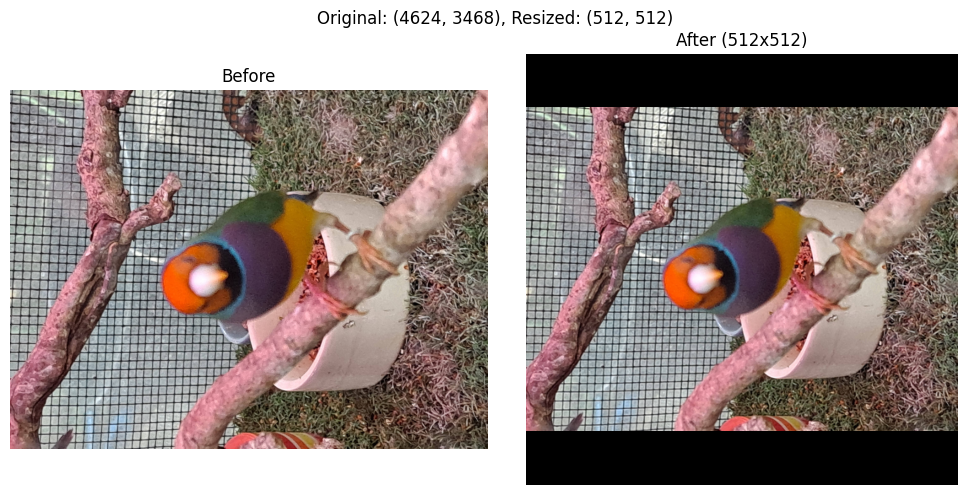

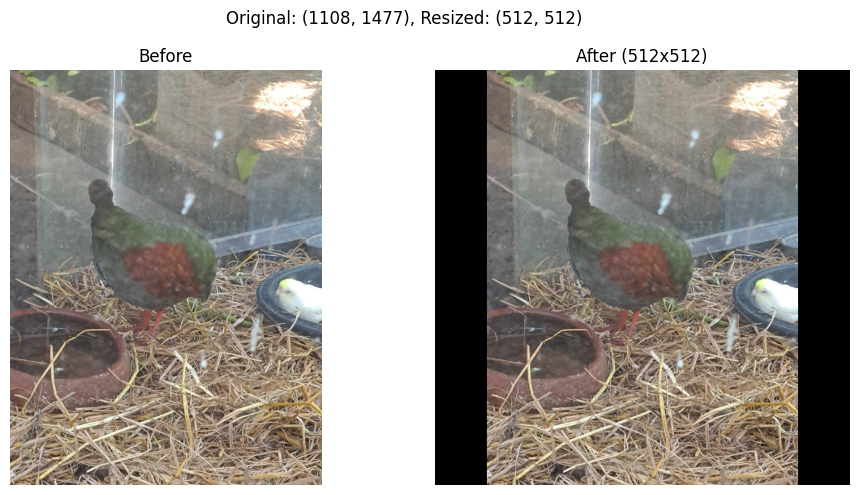

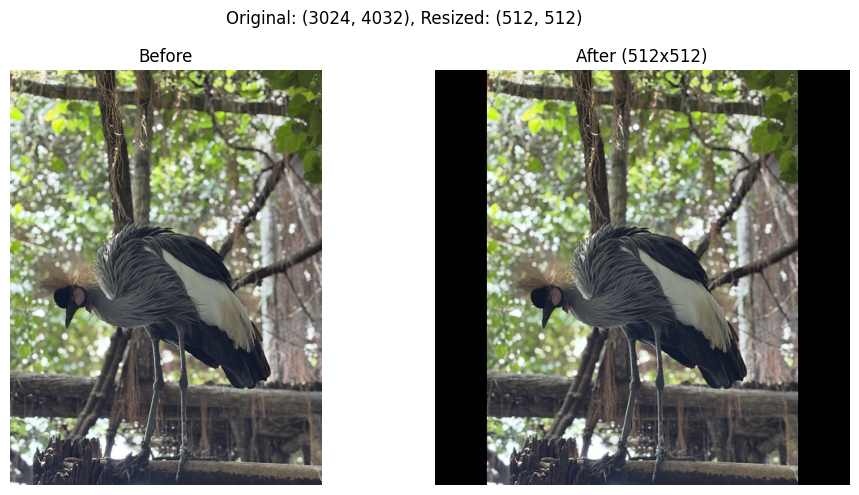

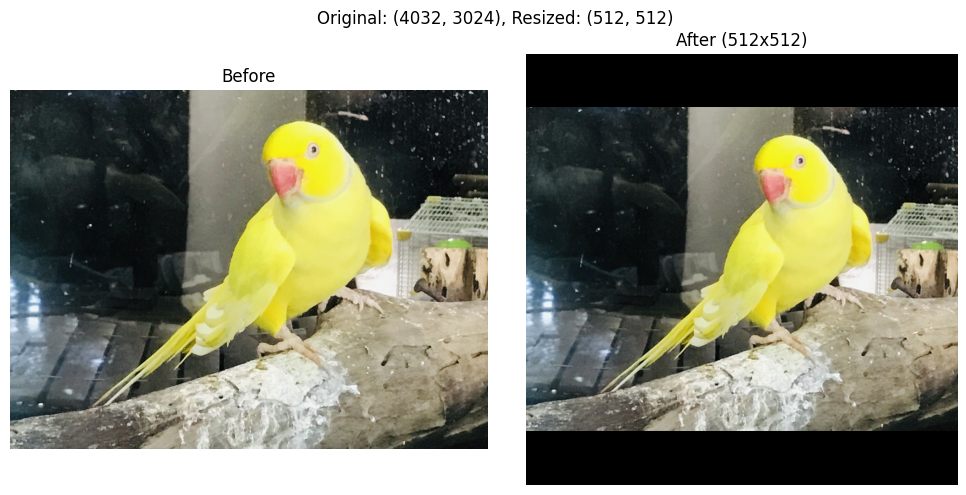

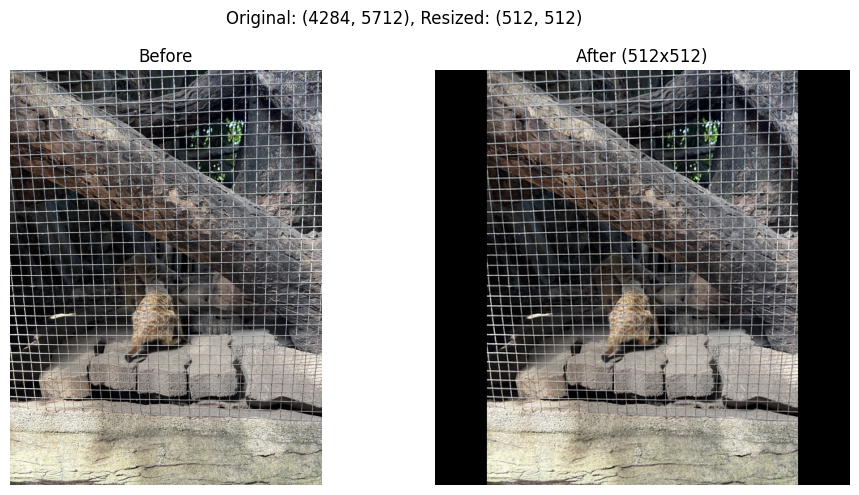

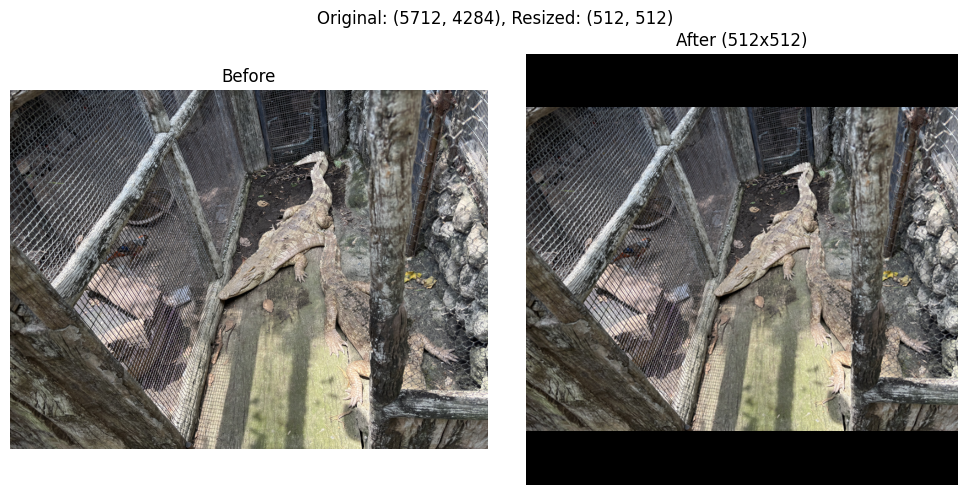

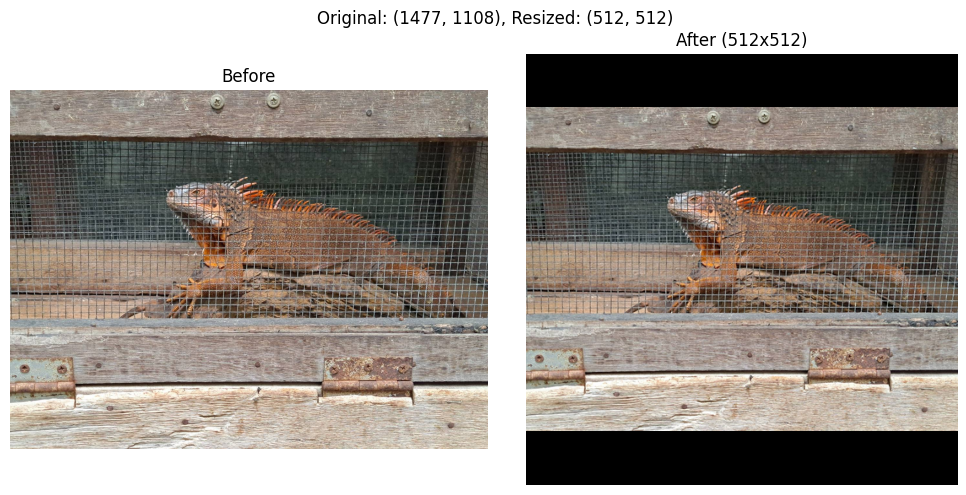

In [21]:
target_size = (512, 512)

size_to_files = defaultdict(list)

for root, _, files in os.walk(data_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            with Image.open(file_path) as img:
                size_to_files[img.size].append(file_path)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")


def resize_with_padding(img, target_size=(512, 512), fill_color=(0, 0, 0)):
    img.thumbnail(target_size, Image.Resampling.LANCZOS)
    delta_w = target_size[0] - img.size[0]
    delta_h = target_size[1] - img.size[1]
    padding = (delta_w // 2, delta_h // 2, delta_w - delta_w // 2, delta_h - delta_h // 2)
    return ImageOps.expand(img, padding, fill=fill_color)


# Display Before/After images for each size (random sample)
for original_size, file_list in sorted(size_to_files.items(), key=lambda x: -len(x[1])):
    sample_file = random.choice(file_list)
    with Image.open(sample_file) as img:
        resized = resize_with_padding(img.copy(), target_size)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        fig.suptitle(f"Original: {img.size}, Resized: {resized.size}", fontsize=12)

        axes[0].imshow(img)
        axes[0].set_title("Before")
        axes[0].axis("off")

        axes[1].imshow(resized)
        axes[1].set_title("After (512x512)")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

In [22]:
target_size = (512, 512)
fill_color_black = (0, 0, 0)

def resize_with_padding(img, target_size=(512,512), fill_color=(0, 0, 0)):
    img.thumbnail(target_size, Image.Resampling.LANCZOS)
    delta_w = target_size[0] - img.size[0]
    delta_h = target_size[1] - img.size[1]
    padding = (delta_w//2, delta_h//2, delta_w - delta_w//2, delta_h - delta_h//2)
    return ImageOps.expand(img, padding, fill=fill_color)

for root, _, files in os.walk(data_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            with Image.open(file_path) as img:
                resized_img = resize_with_padding(img, target_size, fill_color_black)
                resized_img.save(file_path)
        except Exception as e:
            print(f"Error processing {file_path}: {e}")

print("Resize all images done.")


Error processing ../../wildsnap-copy/.DS_Store: cannot identify image file '../../wildsnap-copy/.DS_Store'
Error processing ../../wildsnap-copy/Turtles/.DS_Store: cannot identify image file '../../wildsnap-copy/Turtles/.DS_Store'
Error processing ../../wildsnap-copy/Reptiles/.DS_Store: cannot identify image file '../../wildsnap-copy/Reptiles/.DS_Store'
Error processing ../../wildsnap-copy/Mammals/.DS_Store: cannot identify image file '../../wildsnap-copy/Mammals/.DS_Store'
Error processing ../../wildsnap-copy/Birds/.DS_Store: cannot identify image file '../../wildsnap-copy/Birds/.DS_Store'
Resize all images done.


In [4]:
# Check image sizes in the dataset after changing to 512x512 with padding
image_sizes = defaultdict(int)

for root, _, files in os.walk(data_dir):
    for file in files:
        if file == ".DS_Store":
            continue
        file_path = os.path.join(root, file)
        try:
            with Image.open(file_path) as img:
                size = img.size
                image_sizes[size] += 1
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

print("\nImage Size Summary:\n")
total = 0
for size, count in sorted(image_sizes.items(), key=lambda x: -x[1]):
    print(f"{size[0]:>4}x{size[1]:<4} : {count} images")
    total += count

print(f"\nTotal image files counted: {total}")


Image Size Summary:

 512x512  : 563 images

Total image files counted: 563
